C:\Users\pd905\AppData\Local\Temp\ipykernel_21472\1680926635.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Exported: amcf_concept.svg, amcf_concept.png


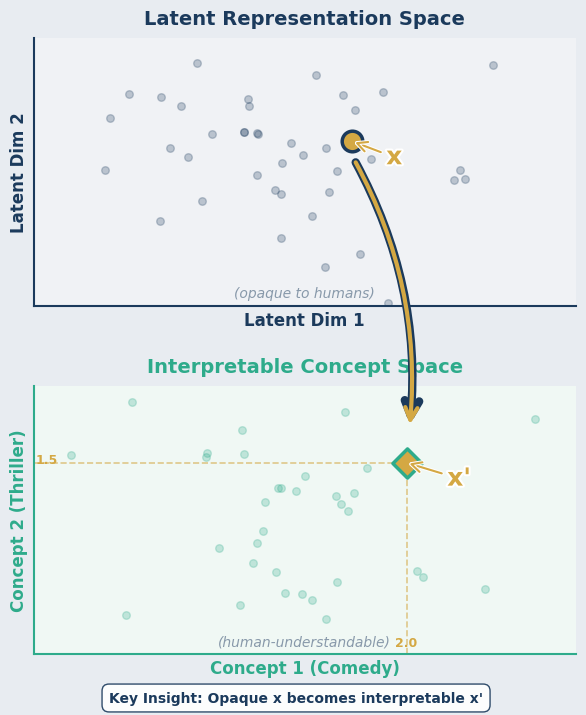

In [11]:
"""
AMCF Concept Diagram v3 — Stacked vertical layout
Latent space (top) → Interpretable concept space (bottom)
Direct arrow from x to x'
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, ConnectionPatch
import numpy as np
import os

saving_path = os.path.join(os.getcwd(), "saved")

# ──────────────────────────────────────────────
# COLOR PALETTE
# ──────────────────────────────────────────────
BG_COLOR = '#E8ECF1'
NAVY     = '#1B3A5C'
TEAL     = '#2EAB8B'
GOLD     = '#D4A843'
RED      = '#C74B4B'
WHITE    = '#FFFFFF'
GRAY     = '#8899AA'

# ──────────────────────────────────────────────
# CONCEPT AXIS NAMES (edit these)
# ──────────────────────────────────────────────
CONCEPT_X_NAME = 'Concept 1 (Comedy)'
CONCEPT_Y_NAME = 'Concept 2 (Thriller)'

# ──────────────────────────────────────────────
# INPUT POINT POSITIONS
# ──────────────────────────────────────────────
X_LATENT  = (1.2, 0.8)     # x in latent space
X_CONCEPT = (2.0, 1.5)     # x' in concept space

# ──────────────────────────────────────────────
# FIGURE
# ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8),
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.30})
fig.patch.set_facecolor(BG_COLOR)

np.random.seed(42)

# ══════════════════════════════════════════════
# TOP: Latent Representation Space
# ══════════════════════════════════════════════
ax1.set_facecolor('#F0F2F5')

# Scatter: random points, no structure
n_points = 40
lx = np.random.randn(n_points) * 1.5 + 0.5
ly = np.random.randn(n_points) * 1.5 + 0.5
ax1.scatter(lx, ly, c=NAVY, s=30, alpha=0.25, zorder=3)

# Highlight x
ax1.scatter([X_LATENT[0]], [X_LATENT[1]], c=GOLD, s=220, zorder=10,
            edgecolors=NAVY, linewidth=2.5)
ann_x = ax1.annotate('x', xy=X_LATENT, xytext=(X_LATENT[0] + 0.5, X_LATENT[1] - 0.6),
                     fontsize=18, fontweight='bold', color=GOLD,
                     arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
                     zorder=11, annotation_clip=False,
                     **{'path_effects': [pe.withStroke(linewidth=3, foreground=WHITE)]})
ann_x.arrow_patch.set_path_effects([pe.withStroke(linewidth=3, foreground=WHITE)])



# Axes
ax1.set_xlabel('Latent Dim 1', fontsize=12, color=NAVY, fontweight='bold')
ax1.set_ylabel('Latent Dim 2', fontsize=12, color=NAVY, fontweight='bold')
ax1.set_title('Latent Representation Space', fontsize=14, color=NAVY,
              fontweight='bold', pad=10)
ax1.text(0.5, 0.02, '(opaque to humans)', transform=ax1.transAxes,
         ha='center', va='bottom', fontsize=10, color=GRAY, style='italic')

ax1.set_xlim(-3.5, 4.5)
ax1.set_ylim(-3.5, 3.5)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color(NAVY)
ax1.spines['bottom'].set_color(NAVY)
for s in ax1.spines.values():
    s.set_linewidth(1.5)

# ══════════════════════════════════════════════
# BOTTOM: Interpretable Concept Space
# ══════════════════════════════════════════════
ax2.set_facecolor('#F0F8F4')

# Scatter: spread out points, no clusters
n_points2 = 35
cx = np.random.randn(n_points2) * 1.8 + 0.5
cy = np.random.randn(n_points2) * 1.8 + 0.3
ax2.scatter(cx, cy, c=TEAL, s=30, alpha=0.25, zorder=3)

# Highlight x'
ax2.scatter([X_CONCEPT[0]], [X_CONCEPT[1]], c=GOLD, s=220, zorder=10,
            edgecolors=TEAL, linewidth=2.5, marker='D')
ann_xp = ax2.annotate("x'", xy=X_CONCEPT, xytext=(X_CONCEPT[0] + 0.6, X_CONCEPT[1] - 0.6),
                      fontsize=18, fontweight='bold', color=GOLD,
                      arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
                      zorder=11, annotation_clip=False,
                      **{'path_effects': [pe.withStroke(linewidth=3, foreground=WHITE)]})
ann_xp.arrow_patch.set_path_effects([pe.withStroke(linewidth=3, foreground=WHITE)])

# Dashed lines from x' to axes to show concept interpretation
ax2.plot([X_CONCEPT[0], X_CONCEPT[0]], [-3.5, X_CONCEPT[1]],
         color=GOLD, linewidth=1.2, linestyle='--', alpha=0.6, zorder=2)
ax2.plot([-3.5, X_CONCEPT[0]], [X_CONCEPT[1], X_CONCEPT[1]],
         color=GOLD, linewidth=1.2, linestyle='--', alpha=0.6, zorder=2)

# Small value labels on axes
ax2.text(X_CONCEPT[0], -3.3, f'{X_CONCEPT[0]:.1f}', ha='center', fontsize=9,
         color=GOLD, fontweight='bold')
ax2.text(-3.3, X_CONCEPT[1], f'{X_CONCEPT[1]:.1f}', ha='center', fontsize=9,
         color=GOLD, fontweight='bold')

# Axes with concept names
ax2.set_xlabel(CONCEPT_X_NAME, fontsize=12, color=TEAL, fontweight='bold')
ax2.set_ylabel(CONCEPT_Y_NAME, fontsize=12, color=TEAL, fontweight='bold')
ax2.set_title('Interpretable Concept Space', fontsize=14, color=TEAL,
              fontweight='bold', pad=10)
ax2.text(0.5, 0.02, '(human-understandable)', transform=ax2.transAxes,
         ha='center', va='bottom', fontsize=10, color=GRAY, style='italic')

ax2.set_xlim(-3.5, 4.5)
ax2.set_ylim(-3.5, 3.5)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(TEAL)
ax2.spines['bottom'].set_color(TEAL)
for s in ax2.spines.values():
    s.set_linewidth(1.5)

# ══════════════════════════════════════════════
# DIRECT ARROW from x to x' across axes
# ══════════════════════════════════════════════
# Offset points so arrow doesn't overlap x and x'
ARROW_START = (X_LATENT[0] + 0.05, X_LATENT[1] - 0.55)
ARROW_END   = (X_CONCEPT[0] + 0.05, X_CONCEPT[1] + 1.0)

# Border arrow (white, thicker, behind the gold one)
arrow_border = ConnectionPatch(
    xyA=ARROW_START, coordsA=ax1.transData,
    xyB=ARROW_END, coordsB=ax2.transData,
    arrowstyle='->', mutation_scale=26,
    color=NAVY, linewidth=6, zorder=19,
    connectionstyle='arc3,rad=-0.15'
)
fig.patches.append(arrow_border)

# Main gold arrow on top
arrow = ConnectionPatch(
    xyA=ARROW_START, coordsA=ax1.transData,
    xyB=ARROW_END, coordsB=ax2.transData,
    arrowstyle='->', mutation_scale=22,
    color=GOLD, linewidth=3, zorder=20,
    connectionstyle='arc3,rad=-0.15'
)
fig.patches.append(arrow)

# # Mapping label next to the arrow
# fig.text(0.72, 0.50, 'Mapping f', ha='center', fontsize=13,
#          fontweight='bold', color=GOLD)
# fig.text(0.72, 0.47, 'faithful, minimal\ninformation loss',
#          ha='center', fontsize=9, color=NAVY, style='italic')

# ══════════════════════════════════════════════
# KEY INSIGHT at bottom
# ══════════════════════════════════════════════
fig.text(0.5, 0.05,
         "Key Insight: Opaque x becomes interpretable x'",
         ha='center', fontsize=10, color=NAVY, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor=WHITE, edgecolor=NAVY, alpha=0.9))

plt.tight_layout()
plt.savefig(os.path.join(saving_path, 'amcf_concept.svg'), format='svg', bbox_inches='tight', facecolor=BG_COLOR)
plt.savefig(os.path.join(saving_path, 'amcf_concept.png'), dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
print("Exported: amcf_concept.svg, amcf_concept.png")
